In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [19]:
mnist=fetch_openml('mnist_784',version=1,as_frame=False)

In [20]:
X=mnist.data
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [21]:
print(X.dtype)
print(X.max())
print(X.min())

int64
255
0


In [22]:
y=mnist.target.astype(int)
print(y)

[5 0 4 ... 4 5 6]


In [23]:
y.dtype

dtype('int64')

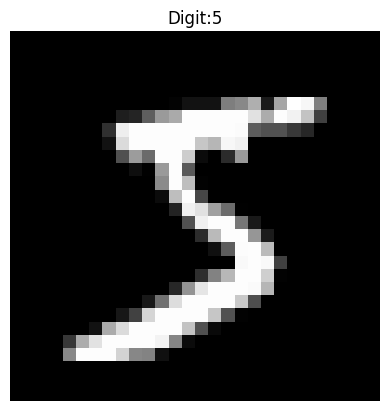

In [24]:
plt.imshow(X[0].reshape(28,28),cmap='gray')
plt.title(f"Digit:{y[0]}")
plt.axis('off')
plt.show()

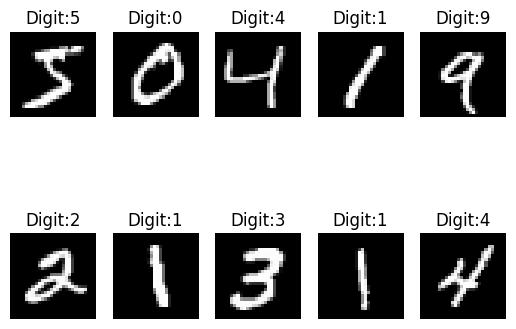

In [25]:
fig,axes=plt.subplots(2,5)

for i,ax in enumerate(axes.ravel()):
  ax.imshow(X[i].reshape(28,28),cmap='gray')
  ax.set_title(f"Digit:{y[i]}")
  ax.axis('off')
plt.show()

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [27]:
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

**Finding Number of Components in PCA**

In [28]:
# Method -1
pca_auto=PCA(n_components=0.95)
X_train_reduced=pca_auto.fit_transform(X_train_scaled)

print("Number of components chosen:",pca_auto.n_components_)
print("Total explained variance:",pca_auto.explained_variance_ratio_.sum())

Number of components chosen: 154
Total explained variance: 0.9503945587155624


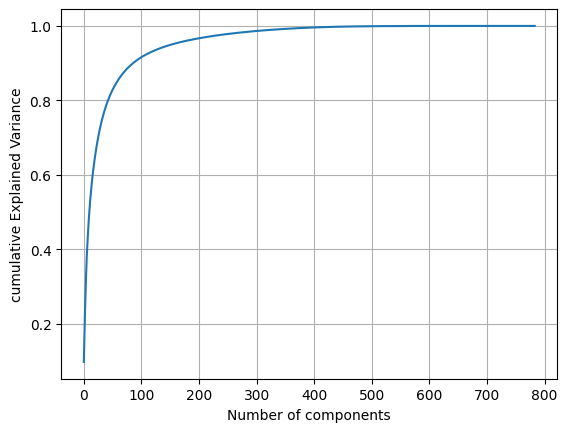

In [29]:
# Method -2 ( Elbow curve)
pca_all=PCA()
pca_all.fit(X_train_scaled)

cumulative_variance=np.cumsum(pca_all.explained_variance_ratio_)

plt.plot(cumulative_variance)
plt.xlabel('Number of components')
plt.ylabel('cumulative Explained Variance')
plt.grid(True)
plt.show()

In [30]:
X_test_reduced=pca_auto.transform(X_test_scaled)

In [31]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [15]:
models = {
    # 'SVC': SVC(probability=True), # Fix 1: Enabled probabilities
    #'DecisionTree': DecisionTreeClassifier(),
    #'GradientBoosting': GradientBoostingClassifier(),
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier()
}

for name, model in models.items():
    print(f"\n{'='*40}\nEvaluating: {name}\n{'='*40}")

    # 1. Train the model on the reduced training data
    model.fit(X_train_reduced, y_train)

    # 2. Get standard predictions for the test set
    predictions = model.predict(X_test_reduced)

    # 3. Calculate basic metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    f1 = f1_score(y_test, predictions, average='weighted')

    # 4. Cross-validate on the TRAINING data (Fix 2)
    # Fix 3: We calculate OVR and OVO in a single run to save massive amounts of time
    cv_results = cross_validate(
        model,
        X_train_reduced,
        y_train,
        cv=5,
        scoring=['roc_auc_ovr', 'roc_auc_ovo']
    )

    # Extract the average scores from the cross-validation
    avg_roc_ovr = np.mean(cv_results['test_roc_auc_ovr'])
    avg_roc_ovo = np.mean(cv_results['test_roc_auc_ovo'])

    # 5. Print out the results in a clean, readable format (Fix 4)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")
    print(f"ROC (OVR): {avg_roc_ovr:.4f} | ROC (OVO): {avg_roc_ovo:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, predictions))


Evaluating: RandomForest
Accuracy:  0.9466
Precision: 0.9465 | Recall: 0.9466 | F1-Score: 0.9465
ROC (OVR): 0.9966 | ROC (OVO): 0.9966

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1381
           1       0.98      0.98      0.98      1575
           2       0.94      0.94      0.94      1398
           3       0.92      0.93      0.93      1428
           4       0.95      0.94      0.95      1365
           5       0.93      0.94      0.93      1263
           6       0.96      0.97      0.97      1375
           7       0.95      0.95      0.95      1459
           8       0.93      0.91      0.92      1365
           9       0.93      0.91      0.92      1391

    accuracy                           0.95     14000
   macro avg       0.95      0.95      0.95     14000
weighted avg       0.95      0.95      0.95     14000


Evaluating: XGBoost
Accuracy:  0.9634
Precision: 0.9633 | Recall: 0.9634 | F1-Sc

**Saving the script**

In [16]:
import joblib

best_xgb=models['XGBoost']

best_xgb.save_model('best_xgb_model.json')
joblib.dump(pca_auto,'mnist_pca_transformer.pkl')

print("XGBoost and PCA successfully saved to disk!")

XGBoost and PCA successfully saved to disk!


**Real image Testing**

In [37]:
import cv2
import numpy as np
import joblib
from xgboost import XGBClassifier

# 1. Load the Model and PCA
loaded_pca = joblib.load('mnist_pca_transformer.pkl')
loaded_xgb = XGBClassifier()
loaded_xgb.load_model('best_xgb_model.json')

def get_best_shift(img):
    """Calculates shifts needed to align the image by its center of mass."""
    cy, cx = center_of_mass(img)
    rows, cols = img.shape
    shiftx = np.round(cols / 2.0 - cx).astype(int)
    shifty = np.round(rows / 2.0 - cy).astype(int)
    return shiftx, shifty

def shift(img, sx, sy):
    """Shifts the image by sx and sy."""
    M = np.float32([[1, 0, sx], [0, 1, sy]])
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

def preprocess_to_mnist(image_path):
    # 1. Read image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")

    # 2. Otsu thresholding to binarize the image cleanly
    _, img_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. FORCE white digit on black background
    # A digit takes up less than 50% of the space.
    # If more than half the image is white, we invert it.
    if np.mean(img_thresh) > 127:
        img_thresh = cv2.bitwise_not(img_thresh)

    # 4. Crop to the tight bounding box around the white digit
    coords = cv2.findNonZero(img_thresh)
    if coords is None:
        raise ValueError("Image is completely blank after thresholding!")
    x, y, w, h = cv2.boundingRect(coords)
    digit = img_thresh[y:y+h, x:x+w]

    # 5. Resize to fit inside a 20x20 box, preserving aspect ratio
    if w > h:
        new_w = 20
        new_h = max(int(h * (20.0 / w)), 1)
    else:
        new_h = 20
        new_w = max(int(w * (20.0 / h)), 1)

    digit_resized = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # 6. Paste inside a blank 28x28 black canvas
    padded = np.zeros((28, 28), dtype=np.uint8)
    start_y = (28 - new_h) // 2
    start_x = (28 - new_w) // 2
    padded[start_y:start_y+new_h, start_x:start_x+new_w] = digit_resized

    # 7. Center the digit using its center of mass (standard MNIST requirement)
    sx, sy = get_best_shift(padded)
    centered = shift(padded, sx, sy)

    return centered

def predict_uploaded_image(image_path, model, pca):
    # Preprocess image to standard MNIST format
    processed_28x28 = preprocess_to_mnist(image_path)

    # Visual sanity check: inspect what the model actually sees
    plt.figure(figsize=(2, 2))
    plt.imshow(processed_28x28, cmap='gray')
    plt.title("Preprocessed Input")
    plt.axis('off')
    plt.show()

    # Scale to [0, 1]
    img_scaled = processed_28x28.astype(np.float64) / 255.0
    img_ready = img_scaled.reshape(1, 784)

    # Transform through PCA
    img_pca = pca.transform(img_ready)

    # Predict
    pred = model.predict(img_pca)
    probs = model.predict_proba(img_pca)
    confidence = np.max(probs) * 100

    print(f"\n---> Predicted Digit: {pred[0]} (Confidence: {confidence:.2f}%) <---")

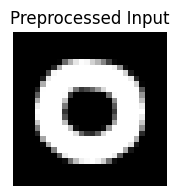


---> Predicted Digit: 0 (Confidence: 99.99%) <---


In [49]:
from scipy.ndimage import center_of_mass
predict_uploaded_image('zero_new.png', loaded_xgb, loaded_pca)